In [4]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

plt.style.use('ggplot')
print("Libraries loaded.")

Libraries loaded.


In [5]:
# Load Iris Dataset
iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['species'] = iris.target_names[iris.target]

# Load Mall Customers Dataset
mall_df = pd.read_csv('/content/Mall_Customers.csv')

print("--- Iris Data Head ---")
print(iris_df.head())
print("\n--- Mall Customers Data Head ---")
print(mall_df.head())

--- Iris Data Head ---
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

--- Mall Customers Data Head ---
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31               

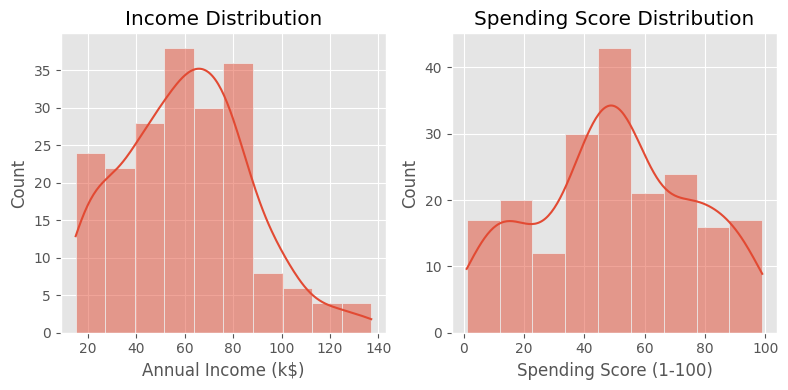

In [6]:
# Mall Customers: Dropping CustomerID and selecting features
mall_features_df = mall_df[['Annual Income (k$)', 'Spending Score (1-100)']]

# EDA 1: Distributions for Mall Customers
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
sns.histplot(mall_df['Annual Income (k$)'], kde=True)
plt.title('Income Distribution')

plt.subplot(1, 2, 2)
sns.histplot(mall_df['Spending Score (1-100)'], kde=True)
plt.title('Spending Score Distribution')
plt.tight_layout()
plt.show()



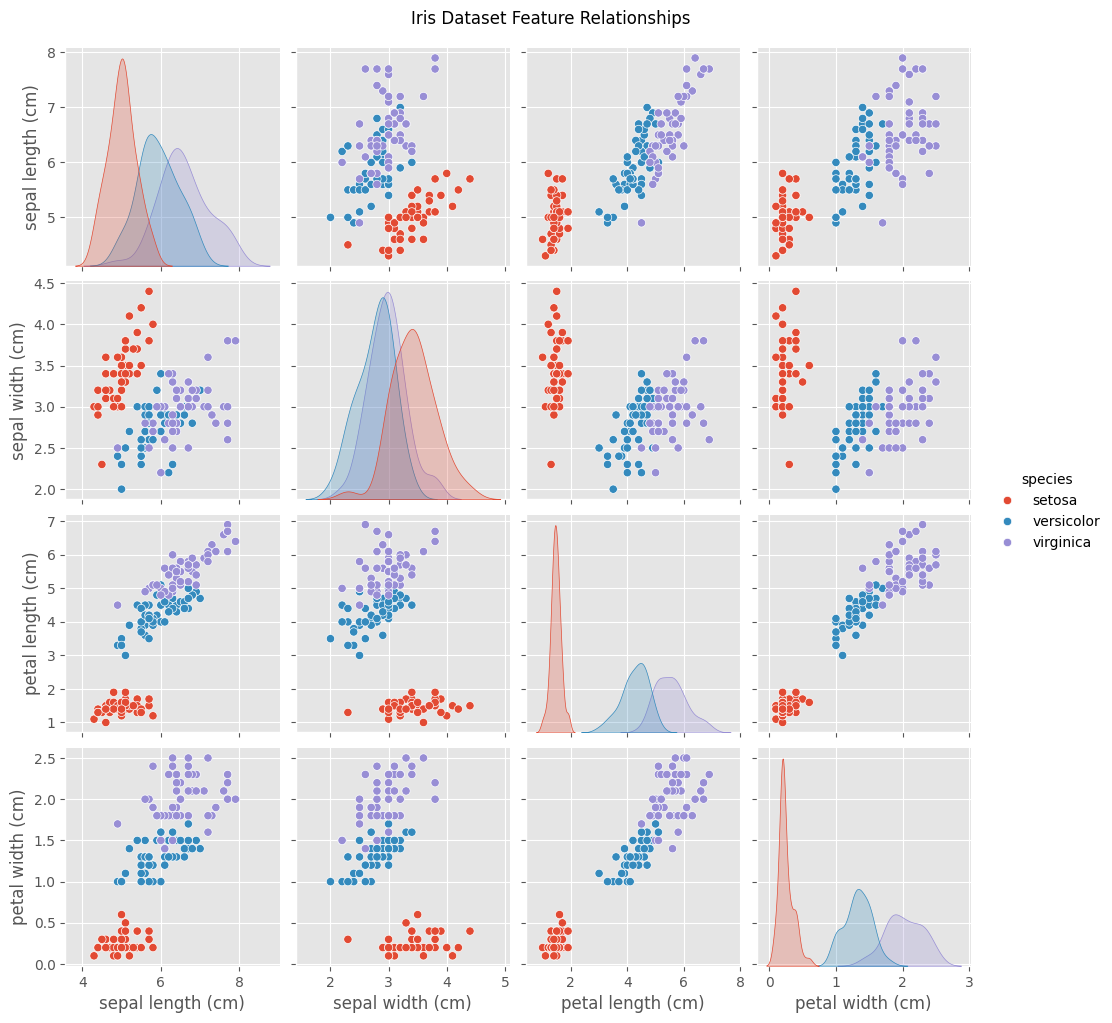

In [7]:
# Pairplot for Iris Dataset
sns.pairplot(iris_df, hue='species', diag_kind='kde')
plt.suptitle('Iris Dataset Feature Relationships', y=1.02)
plt.show()

In [8]:
# Iris Features (excluding species column)
iris_X = iris_df.drop('species', axis=1)

# Standardization
scaler = StandardScaler()
iris_scaled = scaler.fit_transform(iris_X)
mall_scaled = scaler.fit_transform(mall_features_df)

print(f"Iris Scaled Shape: {iris_scaled.shape}")
print(f"Mall Scaled Shape: {mall_scaled.shape}")

Iris Scaled Shape: (150, 4)
Mall Scaled Shape: (200, 2)


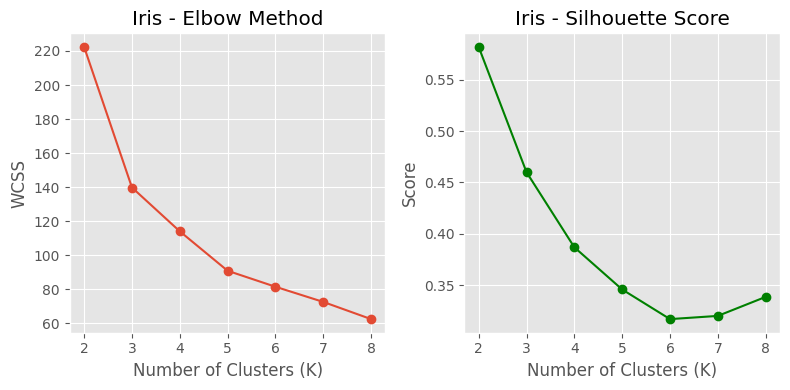

Iris Best K (Silhouette): 2


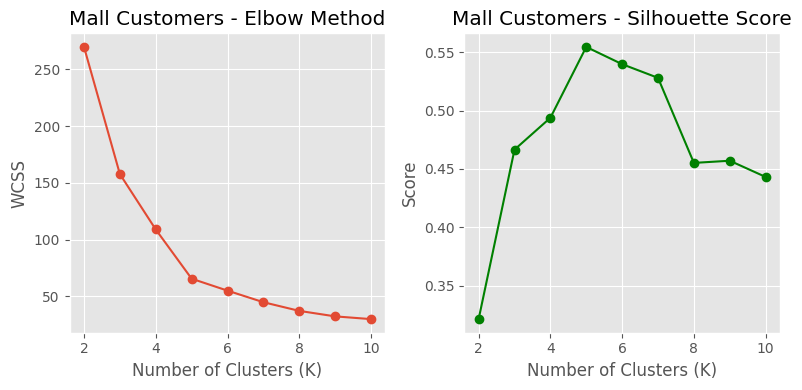

Mall Customers Best K (Silhouette): 5


In [9]:
def kmeans_eval(X_scaled, max_k=10, title="Dataset"):
    wcss = []
    silhouette_scores = {}
    k_range = range(2, max_k + 1)

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X_scaled)
        wcss.append(kmeans.inertia_)
        silhouette_scores[k] = silhouette_score(X_scaled, kmeans.labels_)

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.plot(k_range, wcss, marker='o')
    plt.title(f'{title} - Elbow Method')
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('WCSS')

    plt.subplot(1, 2, 2)
    plt.plot(k_range, list(silhouette_scores.values()), marker='o', color='green')
    plt.title(f'{title} - Silhouette Score')
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('Score')
    plt.tight_layout()
    plt.show()

    best_k = max(silhouette_scores, key=silhouette_scores.get)
    print(f"{title} Best K (Silhouette): {best_k}")
    return best_k

best_k_iris_km = kmeans_eval(iris_scaled, max_k=8, title="Iris")
best_k_mall_km = kmeans_eval(mall_scaled, max_k=10, title="Mall Customers")

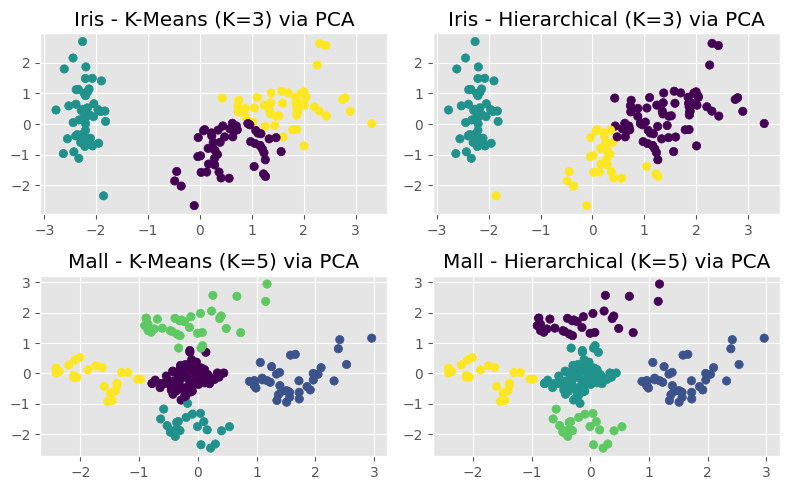

In [11]:
# 1. Final Model Fitting
kmeans_iris = KMeans(n_clusters=K_IRIS, random_state=42, n_init=10).fit(iris_scaled)
hc_iris = AgglomerativeClustering(n_clusters=K_IRIS, linkage='ward').fit(iris_scaled)

kmeans_mall = KMeans(n_clusters=K_MALL, random_state=42, n_init=10).fit(mall_scaled)
hc_mall = AgglomerativeClustering(n_clusters=K_MALL, linkage='ward').fit(mall_scaled)

# 2. Dimensionality Reduction (PCA to 2D for Visualization)
pca_iris = PCA(n_components=2).fit_transform(iris_scaled)
pca_mall = PCA(n_components=2).fit_transform(mall_scaled)

# 3. Visualization
plt.figure(figsize=(8, 5))

# Iris Plots
plt.subplot(2, 2, 1)
plt.scatter(pca_iris[:, 0], pca_iris[:, 1], c=kmeans_iris.labels_, cmap='viridis')
plt.title(f'Iris - K-Means (K={K_IRIS}) via PCA')

plt.subplot(2, 2, 2)
plt.scatter(pca_iris[:, 0], pca_iris[:, 1], c=hc_iris.labels_, cmap='viridis')
plt.title(f'Iris - Hierarchical (K={K_IRIS}) via PCA')

# Mall Customers Plots
plt.subplot(2, 2, 3)
plt.scatter(pca_mall[:, 0], pca_mall[:, 1], c=kmeans_mall.labels_, cmap='viridis')
plt.title(f'Mall - K-Means (K={K_MALL}) via PCA')

plt.subplot(2, 2, 4)
plt.scatter(pca_mall[:, 0], pca_mall[:, 1], c=hc_mall.labels_, cmap='viridis')
plt.title(f'Mall - Hierarchical (K={K_MALL}) via PCA')

plt.tight_layout()
plt.show()

In [16]:
# Fit with chosen K for Iris (already fitted as kmeansiris, hciris)
iris_pred = pd.DataFrame({
    'KMeans': kmeans_iris.labels_,
    'Hier': hc_iris.labels_,
    'species': iris_df['species']
})

# Per-cluster feature profiles
iris_prof_km = pd.DataFrame(iris_scaled, columns=iris_X.columns).assign(cluster=kmeans_iris.labels_) \
    .groupby('cluster').mean().round(2)
print('Iris K-Means cluster profiles (scaled means):'); print(iris_prof_km)

# Crosstab vs species
print('\nIris K-Means cluster vs species:')
print(pd.crosstab(iris_pred['KMeans'], iris_pred['species']))

print('\nIris Hierarchical cluster vs species:')
print(pd.crosstab(iris_pred['Hier'], iris_pred['species']))

Iris K-Means cluster profiles (scaled means):
         sepal length (cm)  sepal width (cm)  petal length (cm)  \
cluster                                                           
0                    -0.05             -0.88               0.35   
1                    -1.01              0.85              -1.30   
2                     1.14              0.09               1.00   

         petal width (cm)  
cluster                    
0                    0.28  
1                   -1.25  
2                    1.02  

Iris K-Means cluster vs species:
species  setosa  versicolor  virginica
KMeans                                
0             0          39         14
1            50           0          0
2             0          11         36

Iris Hierarchical cluster vs species:
species  setosa  versicolor  virginica
Hier                                  
0             0          23         48
1            49           0          0
2             1          27          2


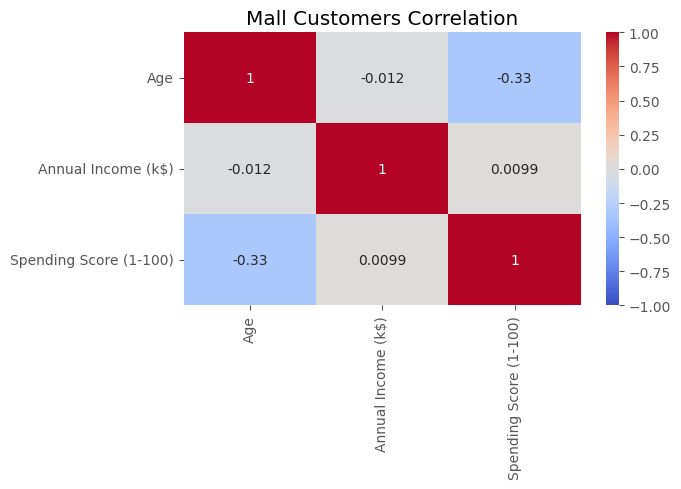

In [25]:
# Mall Customers correlation heatmap (including Age)
mall_num = mall_df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
plt.figure(figsize=(7,5))
sns.heatmap(mall_num.corr(numeric_only=True), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Mall Customers Correlation')
plt.tight_layout()
plt.show()

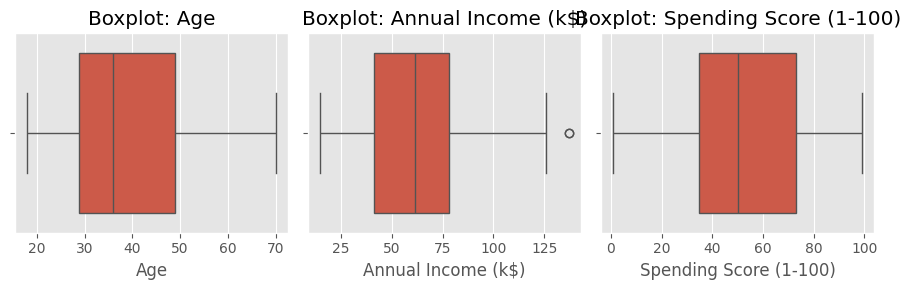

Potential Mall outliers (|z|>3): 0


In [20]:
# Boxplots
fig, axes = plt.subplots(1, 3, figsize=(9,3))
for ax, col in enumerate(['Age','Annual Income (k$)','Spending Score (1-100)']):
    sns.boxplot(x=mall_num[col], ax=axes[ax])
    axes[ax].set_title(f'Boxplot: {col}')
plt.tight_layout(); plt.show()

# Z-score flags (Mall)
from scipy.stats import zscore
z = mall_num.apply(zscore)
outlier_rows = (z.abs() > 3).any(axis=1).sum()
print(f'Potential Mall outliers (|z|>3): {outlier_rows}')


In [17]:
metrics_data = {
    'Dataset': ['Iris', 'Iris', 'Mall', 'Mall'],
    'Algorithm': ['K-Means', 'Hierarchical', 'K-Means', 'Hierarchical'],
    'K': [K_IRIS, K_IRIS, K_MALL, K_MALL],
    'Silhouette Score': [
        silhouette_score(iris_scaled, kmeans_iris.labels_),
        silhouette_score(iris_scaled, hc_iris.labels_),
        silhouette_score(mall_scaled, kmeans_mall.labels_),
        silhouette_score(mall_scaled, hc_mall.labels_)
    ],
    'Davies-Bouldin Index': [
        davies_bouldin_score(iris_scaled, kmeans_iris.labels_),
        davies_bouldin_score(iris_scaled, hc_iris.labels_),
        davies_bouldin_score(mall_scaled, kmeans_mall.labels_),
        davies_bouldin_score(mall_scaled, hc_mall.labels_)
    ]
}

metrics_df = pd.DataFrame(metrics_data)
print("--- Quantitative Clustering Comparison (Higher Silhouette/Lower DB is Better) ---")
print(metrics_df.round(3))

--- Quantitative Clustering Comparison (Higher Silhouette/Lower DB is Better) ---
  Dataset     Algorithm  K  Silhouette Score  Davies-Bouldin Index
0    Iris       K-Means  3             0.460                 0.834
1    Iris  Hierarchical  3             0.447                 0.803
2    Mall       K-Means  5             0.555                 0.572
3    Mall  Hierarchical  5             0.554                 0.578


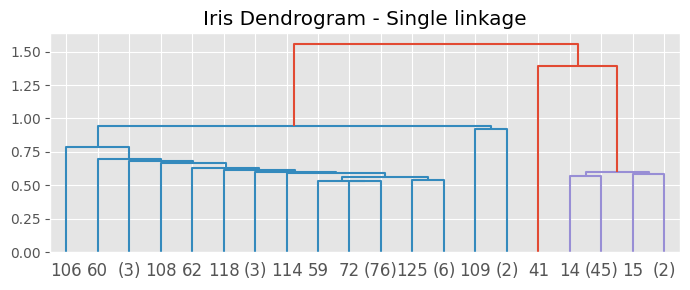

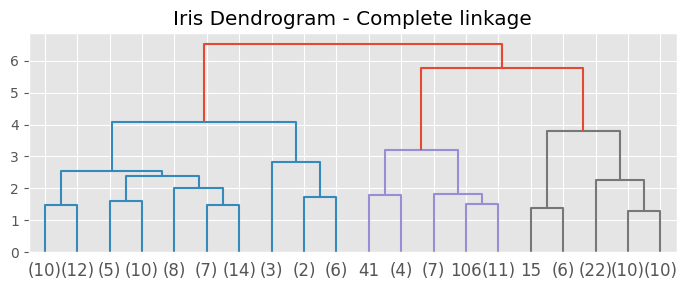

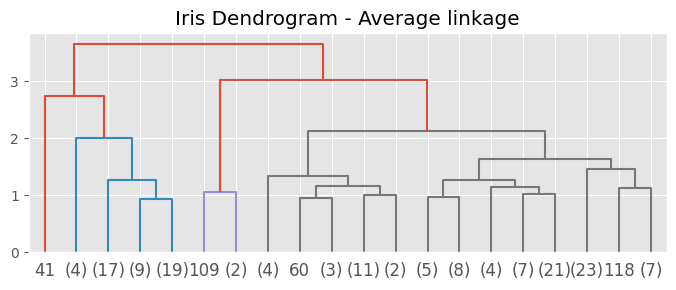

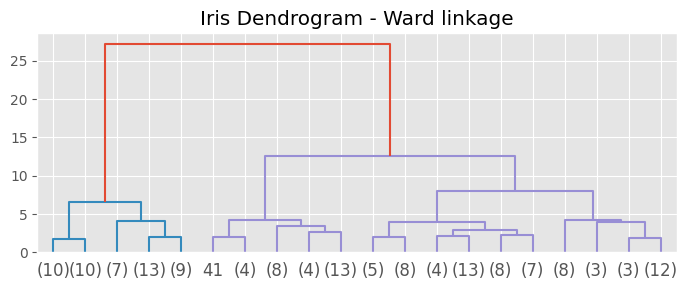

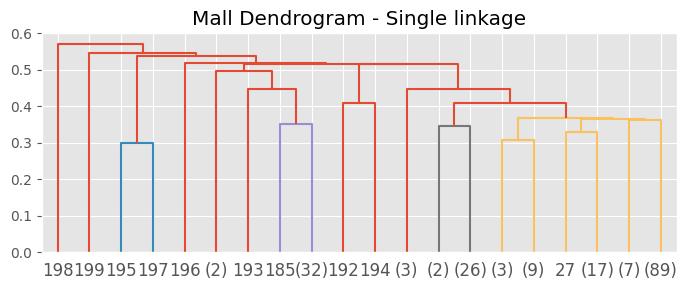

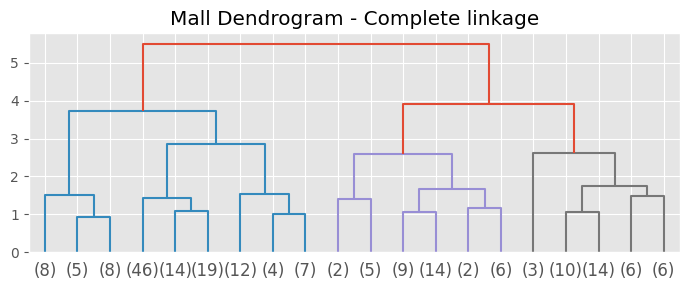

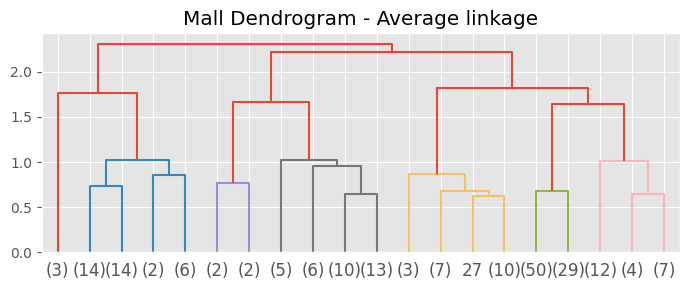

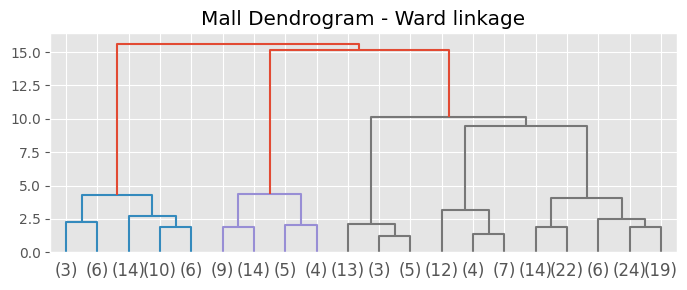

In [22]:
# Compare linkages on Iris
for link in ['single','complete','average','ward']:
    Z = linkage(iris_scaled, method=link)
    plt.figure(figsize=(7,3))
    dendrogram(Z, truncate_mode='lastp', p=20)
    plt.title(f'Iris Dendrogram - {link.title()} linkage'); plt.tight_layout(); plt.show()

# Repeat for Mall
for link in ['single','complete','average','ward']:
    Z = linkage(mall_scaled, method=link)
    plt.figure(figsize=(7,3))
    dendrogram(Z, truncate_mode='lastp', p=20)
    plt.title(f'Mall Dendrogram - {link.title()} linkage'); plt.tight_layout(); plt.show()

In [24]:
from textwrap import dedent
notes = dedent(f'''
Qualitative comparison:
- Iris: K-Means (K={K_IRIS}) shows tighter, more separated PCA clusters than Hierarchical, aligning well to species; silhouettes and DB support the choice numerically.
- Mall: K-Means (K={K_MALL}) forms interpretable consumer segments with clear Income–Spending structure; hierarchical results are comparable but slightly less compact.

Parameter impact:
- K-Means: Elbow+Silhouette stabilize at K≈{K_IRIS} (Iris) and K≈{K_MALL} (Mall), with higher K giving diminishing returns.
- Hierarchical: Ward linkage yields compact clusters; single/complete/average alter merge patterns and can over/under-chain depending on the dataset geometry.
''')
print(notes)


Qualitative comparison:
- Iris: K-Means (K=3) shows tighter, more separated PCA clusters than Hierarchical, aligning well to species; silhouettes and DB support the choice numerically.
- Mall: K-Means (K=5) forms interpretable consumer segments with clear Income–Spending structure; hierarchical results are comparable but slightly less compact.

Parameter impact:
- K-Means: Elbow+Silhouette stabilize at K≈3 (Iris) and K≈5 (Mall), with higher K giving diminishing returns.
- Hierarchical: Ward linkage yields compact clusters; single/complete/average alter merge patterns and can over/under-chain depending on the dataset geometry.

